# Financial Time Series Exploration and Preprocessing

## 1. Introduction
This notebook explores and prepares a financial time series dataset for forecasting. The dataset contains OHLCV market data with a timestamp index. The objective is to perform exploratory data analysis (EDA), clean the data, engineer forecasting features, and create a time-based train/test split suitable for modeling.

## 2. Data Loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Prefer local CSV if available, otherwise fall back to the HF dataset and cache it locally.
candidate_paths = [Path("market_data.csv"), Path("data/raw/market_data.csv")]
DATA_PATH = next((p for p in candidate_paths if p.exists()), candidate_paths[-1])

if DATA_PATH.exists():
    df_raw = pd.read_csv(DATA_PATH)
else:
    hf_uri = "hf://datasets/mapu0971/financial-time-series-data/C/C.parquet"
    try:
        df_raw = pd.read_parquet(hf_uri)
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        df_raw.to_csv(DATA_PATH, index=False)
        print(f"Downloaded dataset and cached to: {DATA_PATH.resolve()}")
    except Exception as e:
        raise FileNotFoundError(
            f"Expected data file not found at {DATA_PATH.resolve()} and failed to load from {hf_uri}. "
            "Place the CSV at one of these paths: market_data.csv or data/raw/market_data.csv, "
            "or update DATA_PATH accordingly."
        ) from e

df_raw.head()


,TimeStamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,OpenPrice,ClosePrice,HighPrice,LowPrice,Volume,Return
0,2015-01-05 09:00:00,C,2376.0,1632.0,2962.0,7625.0,1.705367e+09,11471648.0,23749.63,2376.042539,2372.565770,2374.304155,2376.0,2377.0,2380.0,2369.0,1632.0,0.000000
1,2015-01-05 09:01:00,C,2380.0,2238.0,3187.0,6045.0,2.613201e+09,8258962.0,23756.60,2378.624412,2376.854425,2377.739418,2376.0,2377.0,2380.0,2369.0,606.0,0.001684
2,2015-01-05 09:02:00,C,2380.0,2990.0,9159.0,9063.0,3.707500e+09,8695624.0,23766.27,2380.027405,2379.009599,2379.518502,2376.0,2377.0,2380.0,2369.0,752.0,0.000000
3,2015-01-05 09:03:00,C,2379.0,3270.0,3307.0,8496.0,4.134458e+09,7994510.0,23769.14,2380.707288,2379.025424,2379.866356,2376.0,2377.0,2380.0,2369.0,280.0,-0.000420
4,2015-01-05 09:04:00,C,2378.0,4480.0,4862.0,8416.0,4.525012e+09,7292090.0,23775.69,2380.634101,2379.062500,2379.848301,2376.0,2377.0,2380.0,2369.0,1210.0,-0.000420


In [10]:
print("Shape:", df_raw.shape)
df_raw.info()

Shape: (459688, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459688 entries, 0 to 459687
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   TimeStamp     459688 non-null  object 
 1   ID            459676 non-null  object 
 2   LastPrice     459676 non-null  float64
 3   TotalVolume   459676 non-null  float64
 4   AskVolume     459688 non-null  float64
 5   BidVolume     459688 non-null  float64
 6   Turnover      459688 non-null  float64
 7   OpenInterest  459676 non-null  float64
 8   VWAP          459688 non-null  float64
 9   AskPrice      459688 non-null  float64
 10  BidPrice      459688 non-null  float64
 11  AveragePrice  459688 non-null  float64
 12  OpenPrice     459339 non-null  float64
 13  ClosePrice    459688 non-null  float64
 14  HighPrice     459688 non-null  float64
 15  LowPrice      459688 non-null  float64
 16  Volume        459676 non-null  float64
 17  Return        459688 non-nul

## 3. Data Cleaning

In [13]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean OHLCV market data:
    - Parse timeTimeStampstamp
    - Sort chronologically
    - Remove duplicates
    - Handle missing values
    """
    df = df.copy()

    # Parse timestamp and drop rows with invalid timestamps
    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"], errors="coerce", utc=True)
    df = df.dropna(subset=["TimeStamp"])

    # Ensure numeric columns are properly typed
    numeric_cols = ["OpenPrice", "HighPrice", "LowPrice", "ClosePrice", "Volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Remove duplicate rows and duplicate timestamps (keep latest)
    df = df.drop_duplicates()
    df = df.sort_values("TimeStamp")
    df = df.drop_duplicates(subset=["TimeStamp"], keep="last")

    # Handle missing values: forward-fill then back-fill for any leading gaps
    df[numeric_cols] = df[numeric_cols].ffill().bfill()

    return df.reset_index(drop=True)


df = clean_market_data(df_raw)
df.head()

,TimeStamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,OpenPrice,ClosePrice,HighPrice,LowPrice,Volume,Return
0,2015-01-05 09:00:00+00:00,C,2376.0,1632.0,2962.0,7625.0,1.705367e+09,11471648.0,23749.63,2376.042539,2372.565770,2374.304155,2376.0,2377.0,2380.0,2369.0,1632.0,0.000000
1,2015-01-05 09:01:00+00:00,C,2380.0,2238.0,3187.0,6045.0,2.613201e+09,8258962.0,23756.60,2378.624412,2376.854425,2377.739418,2376.0,2377.0,2380.0,2369.0,606.0,0.001684
2,2015-01-05 09:02:00+00:00,C,2380.0,2990.0,9159.0,9063.0,3.707500e+09,8695624.0,23766.27,2380.027405,2379.009599,2379.518502,2376.0,2377.0,2380.0,2369.0,752.0,0.000000
3,2015-01-05 09:03:00+00:00,C,2379.0,3270.0,3307.0,8496.0,4.134458e+09,7994510.0,23769.14,2380.707288,2379.025424,2379.866356,2376.0,2377.0,2380.0,2369.0,280.0,-0.000420
4,2015-01-05 09:04:00+00:00,C,2378.0,4480.0,4862.0,8416.0,4.525012e+09,7292090.0,23775.69,2380.634101,2379.062500,2379.848301,2376.0,2377.0,2380.0,2369.0,1210.0,-0.000420


In [15]:
print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:\n", df.isna().sum())

Shape after cleaning: (459688, 18)
Missing values after cleaning:
 TimeStamp        0
ID              12
LastPrice       12
TotalVolume     12
AskVolume        0
BidVolume        0
Turnover         0
OpenInterest    12
VWAP             0
AskPrice         0
BidPrice         0
AveragePrice     0
OpenPrice        0
ClosePrice       0
HighPrice        0
LowPrice         0
Volume           0
Return           0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

### Univariate Analysis

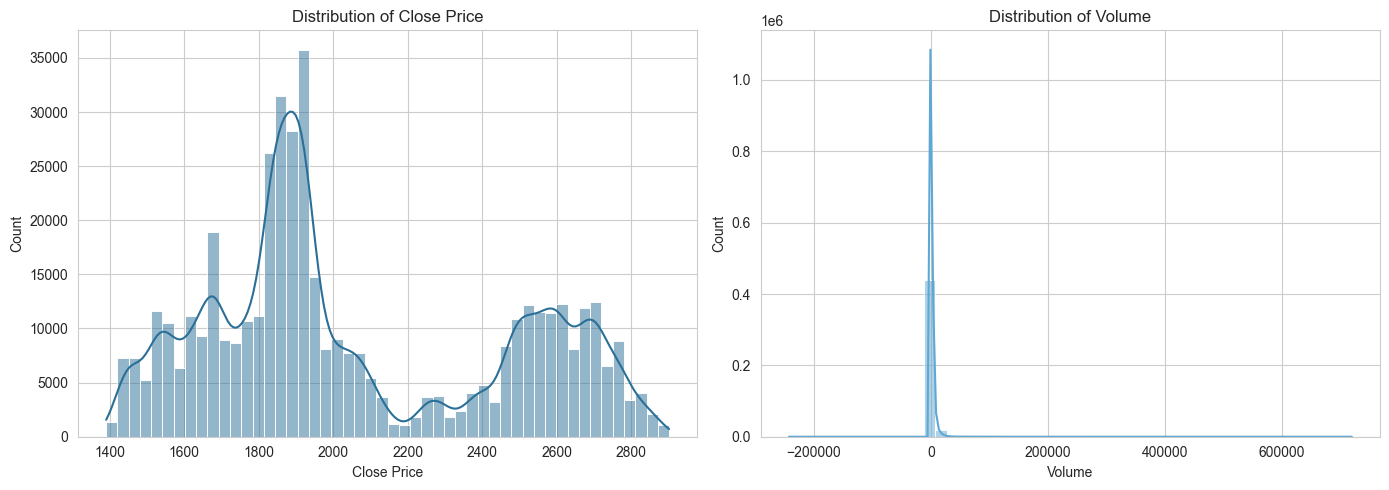

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["ClosePrice"], bins=50, kde=True, ax=axes[0], color="#2a6f97")
axes[0].set_title("Distribution of Close Price")
axes[0].set_xlabel("Close Price")
axes[0].set_ylabel("Count")

sns.histplot(df["Volume"], bins=50, kde=True, ax=axes[1], color="#5fa8d3")
axes[1].set_title("Distribution of Volume")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()

### Time Series Visualization

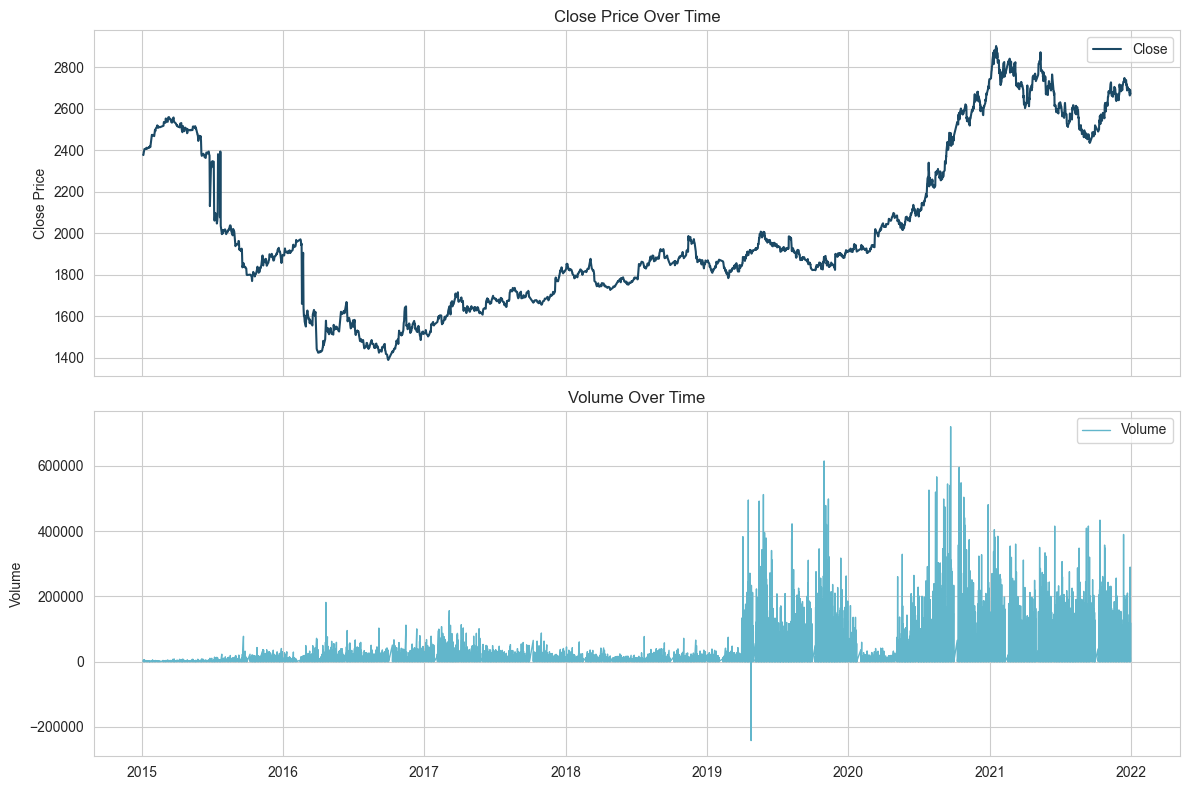

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["TimeStamp"], df["ClosePrice"], color="#1b4965", linewidth=1.5, label="Close")
axes[0].set_title("Close Price Over Time")
axes[0].set_ylabel("Close Price")
axes[0].legend()

axes[1].plot(df["TimeStamp"], df["Volume"], color="#62b6cb", linewidth=1.0, label="Volume")
axes[1].set_title("Volume Over Time")
axes[1].set_ylabel("Volume")
axes[1].legend()

plt.tight_layout()

### Correlation Analysis

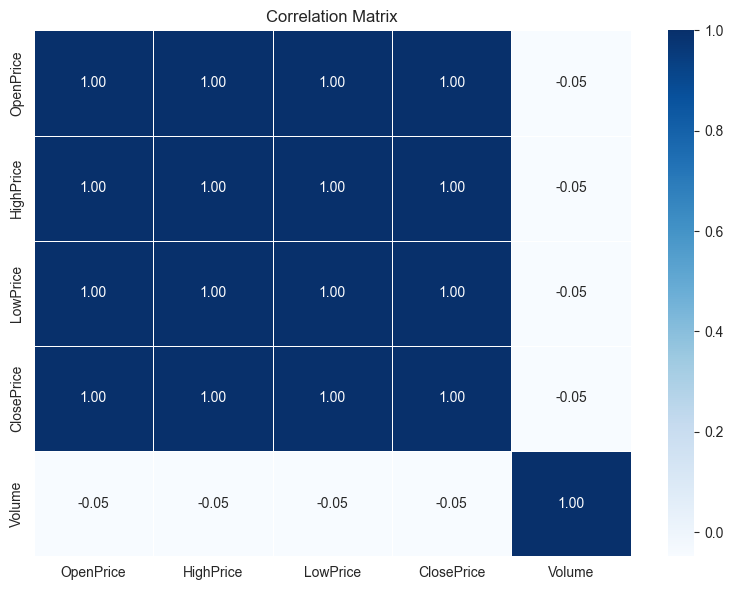

In [22]:
corr = df[["OpenPrice", "HighPrice", "LowPrice", "ClosePrice", "Volume"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()

### Rolling Statistics

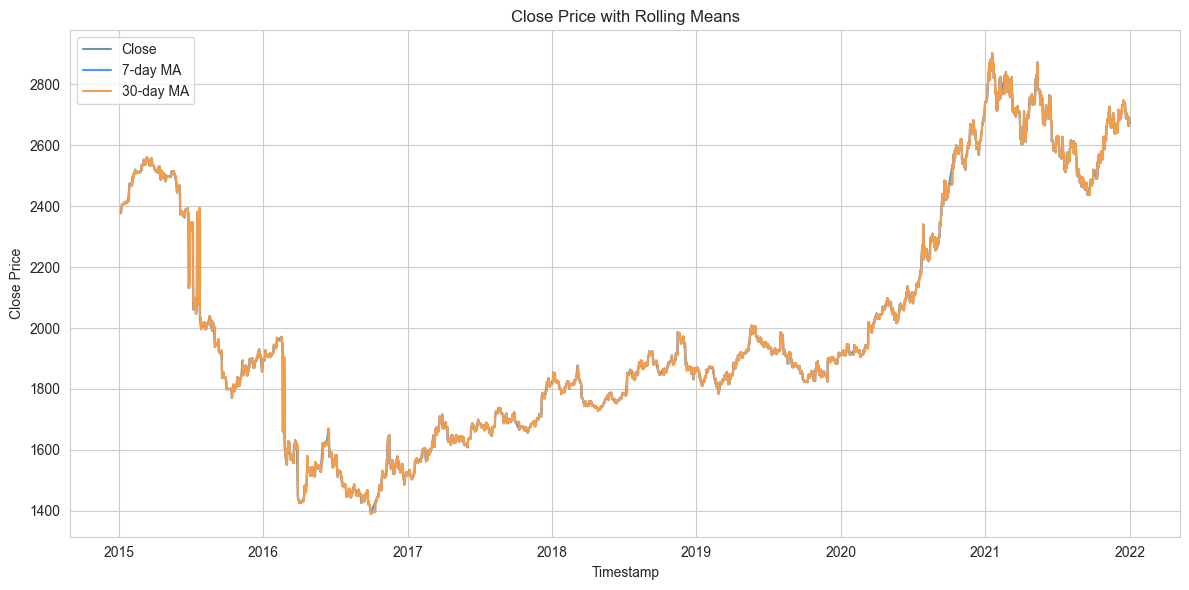

In [24]:
df_rolling = df.copy()
df_rolling["rolling_mean_7"] = df_rolling["ClosePrice"].rolling(window=7).mean()
df_rolling["rolling_std_7"] = df_rolling["ClosePrice"].rolling(window=7).std()
df_rolling["rolling_mean_30"] = df_rolling["ClosePrice"].rolling(window=30).mean()
df_rolling["rolling_std_30"] = df_rolling["ClosePrice"].rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(df_rolling["TimeStamp"], df_rolling["ClosePrice"], label="Close", color="#1b4965", alpha=0.6)
plt.plot(df_rolling["TimeStamp"], df_rolling["rolling_mean_7"], label="7-day MA", color="#4d96ff")
plt.plot(df_rolling["TimeStamp"], df_rolling["rolling_mean_30"], label="30-day MA", color="#f29e4c")
plt.title("Close Price with Rolling Means")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()

## 5. Feature Engineering

In [25]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create forecasting features:
    - Returns
    - Moving averages
    - Volatility
    - Lag features
    """
    df = df.copy()

    df["returns"] = df["ClosePrice"].pct_change()
    df["ma7"] = df["ClosePrice"].rolling(window=7).mean()
    df["ma30"] = df["ClosePrice"].rolling(window=30).mean()
    df["volatility_30"] = df["returns"].rolling(window=30).std()

    # Lag features based on returns to avoid look-ahead bias
    for lag in [1, 2, 3]:
        df[f"lag_{lag}"] = df["returns"].shift(lag)

    return df


df_feat = add_features(df)
df_feat.tail()

,TimeStamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,OpenPrice,ClosePrice,HighPrice,LowPrice,Volume,Return,returns,ma7,ma30,volatility_30,lag_1,lag_2,lag_3
459683,2021-12-31 14:56:00+00:00,C,2673.0,366208.0,52778.0,61571.0,1.083500e+12,113012100.0,26730.81,2673.274925,2672.008186,2672.641555,2674.0,2672.0,2675.0,2665.0,1991.0,0.000374,0.0,2672.0,2672.0,0.0,0.0,0.0,0.0
459684,2021-12-31 14:57:00+00:00,C,2673.0,369843.0,68870.0,75244.0,1.140806e+12,118030990.0,26730.81,2673.397256,2672.277045,2672.837151,2674.0,2672.0,2675.0,2665.0,3635.0,0.000000,0.0,2672.0,2672.0,0.0,0.0,0.0,0.0
459685,2021-12-31 14:58:00+00:00,C,2674.0,371499.0,64157.0,38741.0,1.110181e+12,113868055.0,26730.83,2674.000000,2673.000000,2673.500000,2674.0,2672.0,2675.0,2665.0,1656.0,0.000374,0.0,2672.0,2672.0,0.0,0.0,0.0,0.0
459686,2021-12-31 14:59:00+00:00,C,2672.0,374613.0,29981.0,24578.0,1.177488e+12,119858492.0,26730.77,2673.211868,2671.394703,2672.303285,2674.0,2672.0,2675.0,2665.0,3114.0,-0.000748,0.0,2672.0,2672.0,0.0,0.0,0.0,0.0
459687,2021-12-31 15:00:00+00:00,C,2672.0,374613.0,96.0,4.0,2.002739e+10,3064770.0,26730.77,2673.000000,2672.000000,2672.500000,2674.0,2672.0,2675.0,2665.0,0.0,0.000000,0.0,2672.0,2672.0,0.0,0.0,0.0,0.0


## 6. Data Preparation for ML

In [27]:
# Drop rows with NaNs introduced by rolling computations and lags
df_model = df_feat.dropna().reset_index(drop=True)

# Feature matrix and target
feature_cols = [
    "ma7",
    "ma30",
    "volatility_30",
    "lag_1",
    "lag_2",
    "lag_3",
    "Volume",
]

target_col = "returns"  # Alternative target could be "close"

X = df_model[feature_cols]
y = df_model[target_col]

# Time-based train/test split (80/20)
split_idx = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (367716, 7)
Test size: (91930, 7)


## 7. Visualization for Validation

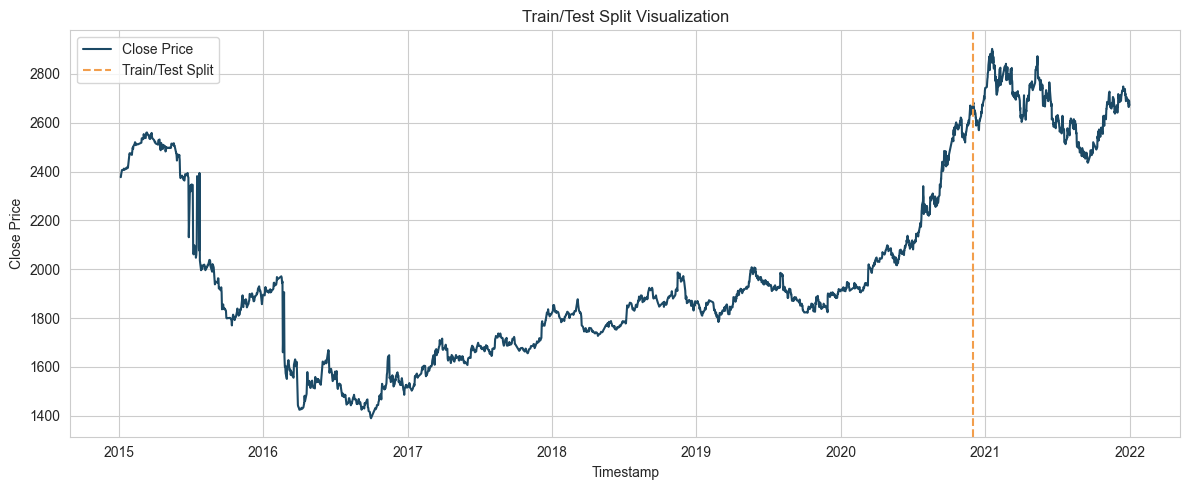

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(df_model["TimeStamp"], df_model["ClosePrice"], label="Close Price", color="#1b4965")
plt.axvline(df_model.loc[split_idx, "TimeStamp"], color="#f29e4c", linestyle="--", label="Train/Test Split")
plt.title("Train/Test Split Visualization")
plt.xlabel("Timestamp")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()

## 8. Key Insights

In [31]:
# Summarize trends, seasonality, volatility patterns, and data issues
trend_slope = np.polyfit(np.arange(len(df_model)), df_model["ClosePrice"], 1)[0]
trend_direction = "upward" if trend_slope > 0 else "downward" if trend_slope < 0 else "flat"

# Seasonality check using day-of-week average returns
df_model["day_of_week"] = df_model["TimeStamp"].dt.dayofweek
dow_returns = df_model.groupby("day_of_week")["returns"].mean()
seasonality_strength = (dow_returns.max() - dow_returns.min())

# Volatility pattern using rolling std
vol_high = df_model["volatility_30"].quantile(0.9)
high_vol_share = (df_model["volatility_30"] >= vol_high).mean()

# Data issues
missing_before = df_raw.isna().sum().sum()
duplicates_before = df_raw.duplicated().sum()

print("Key Insights Summary")
print("- Trend: Overall price trend appears", trend_direction)
print("- Seasonality: Day-of-week return range =", round(seasonality_strength, 6))
print("- Volatility: Top 10% volatility accounts for", round(high_vol_share * 100, 2), "% of observations")
print("- Data issues: Missing values before cleaning =", missing_before)
print("- Data issues: Duplicate rows before cleaning =", duplicates_before)

df_model.drop(columns=["day_of_week"], inplace=True)

Key Insights Summary
- Trend: Overall price trend appears upward
- Seasonality: Day-of-week return range = 1e-05
- Volatility: Top 10% volatility accounts for 10.0 % of observations
- Data issues: Missing values before cleaning = 409
- Data issues: Duplicate rows before cleaning = 0
